In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
NHS-Aligned Conversational Assistant (Offline, Deterministic)

In accordance with NHS guidelines and data governance constraints, 
this script develops a finite state machine (FSM) conversational assistant 
for cognitive rehabilitation that is intended to function fully offline. 

Main Features:
- Offline speech recognition using Vosk (en-US)
- Offline text-to-speech with pyttsx3
- Half-duplex audio handling with start/end beeps
- Deterministic response classification: A* (correct), Ā (incorrect), 
  S (silence), C (critical), FT (free talking, ≥N words; disabled during 
  critical tasks)
- Plain-text logging of all interactions (timestamp, state, prompt, label, 
  confidence) to support audit and reproducibility

FSM Conversation Flow:
S0 Passive Listening
 → S1 Alignment
 → S2 Consent
 → S3 Warm-up (backup on silence)
 → S4 Date Protocol (Introduction → Modelling → Immediate Recall 
    [Ā/S → re-model + re-ask] → Distractor → Delayed Recall)
 → S5 Address Memory Game (Model → Recall #1 [EL retries] → Distractor 
    → Spaced Recall → Functional Check)
 → S6 Closure → return to S0

This code corresponds to the system architecture and integration steps 
described in Dissertation S4 (Implementation) and S4.7 (Integration).
"""


from __future__ import annotations

# Optional COM init for SAPI5 on Windows
try:
    import pythoncom  # noqa: F401
except Exception:
    pythoncom = None  # type: ignore


# Standard library imports
import os, time, json, queue, re, threading, random, uuid, wave, sys
from dataclasses import dataclass, field
from enum import Enum, auto
from datetime import datetime
from typing import Optional, Dict, Tuple

# External libraries
import numpy as np
import sounddevice as sd
import pyttsx3
from vosk import Model, KaldiRecognizer

# ===================== CONFIG (Reproducible) ===================== #

#In case if the code cannot accept the folder please download VOSK Again with the link below
#https://alphacephei.com/vosk/models/vosk-model-en-us-0.42-gigaspeech.zip
#Unzip and place in the codes directory 

# Folder = Code + vosk-model-en-us-0.42-gigaspeech (folder) + Logs txt, start_beep file
# Path to Vosk model directory (must match your local installation)

MODEL_PATH = "vosk-model-en-us-0.42-gigaspeech"

# Microphone audio parameters (Adjustable)
SAMPLE_RATE = 16000
BLOCKSIZE   = 1024
CHANNELS    = 1
DTYPE       = "int16"


# Voice Activity Detection (RMS-based)
VAD_MIN_THRESHOLD_I16   = 120           # Minimum RMS to detect voice
VAD_NOISE_MULTIPLIER    = 1.8           # Multiplier over background noise
VAD_NOISE_EMA_ALPHA     = 0.03          # Noise floor tracking smoothing
PRESENCE_HIT_FRAMES     = 6
PRESENCE_COOLDOWN       = 1.8

# Listen windows
LISTEN_TIMEOUT          = 12.0
PAUSE_AFTER_SPEECH      = 1.3
VAD_FRAMES_SPEECH_START = 2
INITIAL_SILENCE_MAX     = 4.0

# Echo/quiet controls (mute guards around playback)
LEAD_MUTE = 0.25
TAIL_MUTE = 0.25
POST_PLAY_BLOCK_SEC = 0.20
FAST_AFTER_TTS_TAIL = 0.18
PRE_LISTEN_QUIET_SEC = 1.60
ECHO_CLEANUP_SEC     = 0.12

# Quiet gap before speaking (S0 → S1)
QUIET_GAP_BEFORE_SPEAK = 2.0

# TTS configuration
TTS_RATE   = 118
TTS_VOLUME = 0.60

# FT threshold (word count to consider “free talking”) 
FREE_TALKING_MIN_WORDS = 6 

# Passive & pauses
LONG_PASSIVE_SEC          = 300.0
PAUSE_ON_REFUSAL_SEC      = 30.0

# Beeps (start soundeffects )
ENABLE_START_BEEP = True
START_BEEP_WAV    = "start_beep.wav"
ENABLE_ACK_BEEP   = True
ACK_BEEP_WAV      = START_BEEP_WAV
BEEP_TAIL_GUARD   = 0.12
ACK_TAIL_GUARD    = 0.10
ACK_SCALE         = 1.0

#some eyecatching emojis
PRINT_PREFIX_SPEAK = "🤖"
PRINT_PREFIX_HEARD = "🗣️"
PRINT_PREFIX_INFO  = "ℹ️"

# IU (Initial Understanding) micro-check window
IU_MIN_SEC = 3.0
IU_MAX_SEC = 5.0

# Distractor prompts used during EL
DATE_DISTRACTORS = ["Is the light on?", "Can you see a window?", "Is the door open?"]
S5_DISTRACTORS = [
    "Have you had any tea or water today?",
    "Have you brushed your teeth today?",
    "Did you drink water this morning?"
]

# Delayed recall timing (tunable; your tests used ~20s) (used approximate value = 20s)
DELAYED_RECALL_MIN = 18.0
DELAYED_RECALL_MAX = 22.0

# ===================== LOGGING Plain text ===================== #
TXT_LOG_FILE = "nhs_errorless_log.txt"
_txt_lock = threading.Lock()

def _ts_local_ms() -> str:
    now = datetime.now()
    return f"{now.strftime('%Y-%m-%d %H:%M:%S')},{int(now.microsecond/1000):03d}"

def log_txt_response(
    ts_iso: str, session_id: str, state: str, phase: str, prompt_id: str,
    question: str, answer: str, label: str, score: float,
    latency_sec: Optional[float], retries: int, barge_in: bool, distractor: bool
):
    """One-line log in dissertation format: timestamp | Q | A | Label | Score | Latency."""
    q = " ".join((question or "").split())
    a = " ".join((answer or "").split())
    lat_str = f"{latency_sec:.2f}s" if latency_sec is not None else "NA"
    line = f"{_ts_local_ms()} | Q: {q} | A: {a} | Label: {label} | Score: {score:.2f} | Latency: {lat_str}\n"
    with _txt_lock:
        with open(TXT_LOG_FILE, "a", encoding="utf-8") as f:
            f.write(line)

def log_json(_d: dict):
    # Reserved for future; dissertation uses plain-text logs.
    return

# ===================== TEXT/DATE UTILS ===================== #
def now_day_name() -> str:
    return datetime.now().strftime("%A")

def now_date_full() -> str:
    return datetime.now().strftime("%A, %d %B %Y")

def normalize(s: str) -> str:
    # Normalise quotes/whitespace and lowercase for robust matching
    s = s.replace("’", "'")
    return re.sub(r"\s+", " ", s.strip().lower())

def toks(s: str) -> list[str]:
    # Tokenise to alphanumerics for simple rule-based checks
    return re.findall(r"[a-z0-9]+", normalize(s))

def tokset(s: str) -> set[str]:
    return set(toks(s))


# Basic yes/no lexicons (simple grammar constraints)
YES_SET = {"yes","yeah","yep","yup","yah","ok","okay","alright","sure"}
NO_SET  = {"no","nope","nah"}

def is_clear_yes(text: str) -> bool:
    t = tokset(text)
    return bool((t & YES_SET) and not (t & NO_SET))


def is_clear_no(text: str) -> bool:
    t = tokset(text)
    return bool((t & NO_SET) and not (t & YES_SET))



# ===================== RESPONSE TYPES & LABEL MAPPINGS ===================== #
class RType(Enum):
    A_STAR = auto()  # A*
    A_BAR  = auto()   # Ā (wrong/uncertain)
    S      = auto()  # silence
    C      = auto()  # critical
    FT     = auto()  # free talking (>= N words)

LABEL_MAP = {
    RType.A_STAR: "A*",
    RType.A_BAR:  "Ā",
    RType.S:      "S",
    RType.C:      "C",
    RType.FT:     "FT",
}
SCORE_MAP = {
    RType.A_STAR: 1.00,
    RType.A_BAR:  0.50,
    RType.S:      0.00,
    RType.C:      0.00,
    RType.FT:     0.00,
}

# ===================== AUDIO CORE(VAD, PRESENCE, GUARDS) ===================== #
class PresenceMonitor:
    def __init__(self):
        self.last_active = 0.0
        self._hits = 0
        self._lock = threading.Lock()
    def update(self, voice_frame: bool):
        if voice_frame:
            self._hits += 1
            if self._hits >= PRESENCE_HIT_FRAMES:
                with self._lock:
                    self.last_active = time.time()
        else:
            self._hits = max(0, self._hits - 1)
    def recently_active(self) -> bool:
        with self._lock:
            return (time.time() - self.last_active) < PRESENCE_COOLDOWN
    def quiet_for(self, seconds: float) -> bool:
        with self._lock:
            return (time.time() - self.last_active) >= seconds

class AudioEngine:
    # Streams microphone frames, maintains dynamic noise floor, and enforces
    
    # mute/quiet guards to avoid echo and barge-in during TTS/beeps.

    def __init__(self, presence: PresenceMonitor):
        self.presence = presence
        self.q: "queue.Queue[Tuple[np.ndarray, float]]" = queue.Queue(maxsize=128)
        self.listening = False
        self.muted_until = 0.0
        self.stream = None
        self._freeze_noise = False
        self.tts_active = False
        self.capture_paused = False
        self.noise_ema = VAD_MIN_THRESHOLD_I16 * 0.5
        self.rms_last = 0.0
        self.last_voice_time = 0.0

    # --- guards
    def _time_guard_active(self) -> bool:
        return time.time() < self.muted_until
    def is_busy(self) -> bool:
        return self._time_guard_active() or self.capture_paused or self.tts_active
    def set_guard(self, seconds: float):
        self.muted_until = time.time() + seconds
    def set_noise_freeze(self, on: bool):
        self._freeze_noise = on
    def pause_capture(self, on: bool):
        self.capture_paused = on

    def update_noise(self, rms: float):
        self.rms_last = rms
        if not self._freeze_noise:
            self.noise_ema = (1.0 - VAD_NOISE_EMA_ALPHA) * self.noise_ema + VAD_NOISE_EMA_ALPHA * rms
    def dynamic_threshold(self) -> float:
        return max(VAD_MIN_THRESHOLD_I16, self.noise_ema * VAD_NOISE_MULTIPLIER)
    def is_voice(self, rms: float) -> bool:
        return rms > self.dynamic_threshold()

    def _choose_device(self):
        dev = os.environ.get("INPUT_DEVICE", "").strip()
        if not dev:
            return None
        try:
            return int(dev)
        except ValueError:
            for i, d in enumerate(sd.query_devices()):
                if d.get("max_input_channels",0) > 0 and dev.lower() in str(d.get("name","")).lower():
                    return i
            return None

    def start(self):
        # Open input stream with safe defaults and resilience to misconfig

        device_index = self._choose_device()
        try:
            sd.check_input_settings(samplerate=SAMPLE_RATE, device=device_index, channels=CHANNELS, dtype=DTYPE)
        except Exception as e:
            print(f"⚠️  Mic settings check failed ({e}). Falling back to default device.")
            device_index = None

        if device_index is None:
            print("ℹ️ Using default input device.")
        else:
            try:
                dev_info = sd.query_devices(device_index)
                print(f"ℹ️ Using input device: {dev_info.get('name','?')} (index {device_index})")
            except Exception:
                print(f"ℹ️ Using input device index {device_index}")

        def _cb(indata, frames, time_info, status):
            # Real-time audio callback: update VAD, enqueue frames when listening
            s = indata.astype(np.int16)
            rms_i16 = float(np.sqrt(np.mean(np.square(s.astype(np.float32))) + 1e-9))

            if self.is_busy():
                self.rms_last = rms_i16
                return

            self.update_noise(rms_i16)
            voice = self.is_voice(rms_i16)
            self.presence.update(voice)
            if voice:
                self.last_voice_time = time.time()

            if self.listening:
                try:
                    self.q.put_nowait((indata.copy(), rms_i16))
                except queue.Full:
                    pass

        self.stream = sd.InputStream(
            samplerate=SAMPLE_RATE, blocksize=BLOCKSIZE, channels=CHANNELS, dtype=DTYPE,
            callback=_cb, device=device_index
        )
        self.stream.start()

    def stop(self):
        if self.stream:
            self.stream.stop()
            self.stream.close()
            self.stream = None

    def ensure_quiet(self, seconds: float):
         # Block until guards finish and required quiet gap has elapsed
        while self.is_busy():
            time.sleep(0.01)
        # Ensure gap since last voice
        while True:
            gap = time.time() - self.last_voice_time
            if gap >= seconds:
                return
            time.sleep(0.01)

    def drain_queue(self):
        # Drop any buffered frames before a new listen window
        try:
            while True:
                self.q.get_nowait()
        except queue.Empty:
            pass

# ===================== BEEPER (START/ACK CUES WITH SAFETY GUARDS) ===================== #
class Beeper:
    def __init__(self, audio: AudioEngine, start_wav: str, ack_wav: Optional[str]):
        self.audio = audio
        self.data = None
        self.samplerate = None
        self.ack_data = None
        self.ack_sr = None

        # Load start beep
        if ENABLE_START_BEEP and os.path.exists(start_wav):
            with wave.open(start_wav, "rb") as wf:
                self.samplerate = wf.getframerate()
                sw  = wf.getsampwidth()
                raw = wf.readframes(wf.getnframes())
            arr = np.frombuffer(raw, dtype=np.int16 if sw == 2 else np.uint8)
            if sw == 1:
                arr = ((arr.astype(np.int16) - 128) << 8)
            self.data = arr
        
        # Load ack beep or derive from start beep
        if ENABLE_ACK_BEEP:
            if ack_wav and os.path.exists(ack_wav):
                with wave.open(ack_wav, "rb") as wf:
                    self.ack_sr = wf.getframerate()
                    sw  = wf.getsampwidth()
                    raw = wf.readframes(wf.getnframes())
                arr = np.frombuffer(raw, dtype=np.int16 if sw == 2 else np.uint8)
                if sw == 1:
                    arr = ((arr.astype(np.int16) - 128) << 8)
                self.ack_data = arr
            elif self.data is not None and self.samplerate:
                self.ack_sr = self.samplerate
                self.ack_data = (self.data.astype(np.int16) * ACK_SCALE).astype(np.int16)

    def _play_array(self, arr: np.ndarray, sr: int, tail_guard: float):
        # Play a short cue with capture freeze + guards to avoid echo contamination

        if arr is None or sr is None:
            return
        self.audio.pause_capture(True)
        self.audio.set_noise_freeze(True)
        try:
            self.audio.set_guard(LEAD_MUTE + tail_guard + POST_PLAY_BLOCK_SEC + 0.05)
            time.sleep(LEAD_MUTE)
            sd.play(arr, sr, blocking=True)
            time.sleep(ECHO_CLEANUP_SEC)
        finally:
            self.audio.set_noise_freeze(False)
            self.audio.pause_capture(False)
            self.audio.set_guard(tail_guard + POST_PLAY_BLOCK_SEC)

    def play_start(self):
        if not ENABLE_START_BEEP or self.data is None: return
        self._play_array(self.data, self.samplerate, BEEP_TAIL_GUARD)

    def play_ack(self):
        if not ENABLE_ACK_BEEP or self.ack_data is None: return
        self._play_array(self.ack_data, self.ack_sr, ACK_TAIL_GUARD)

# ===================== TTS SPeaker (pyttsx3) WITH THREAD-SAFE LOOP ===================== #
class Speaker:
    # Dedicated TTS worker thread; integrates with audio guards for half-duplex

    def __init__(self, audio: AudioEngine, presence: PresenceMonitor):
        self.audio = audio
        self.presence = presence
        self._tts_lock = threading.RLock()
        self._q: "queue.Queue[Tuple[Optional[str], Optional[threading.Event], float]]" = queue.Queue()
        self._done_events: Dict[str, threading.Event] = {}
        self._shutdown = threading.Event()
        self._engine_ready = threading.Event()
        self._worker = threading.Thread(target=self._tts_loop, daemon=True)
        self._worker.start()
        self._engine_ready.wait(timeout=5.0)

    def _init_engine(self):
        driver = None
        if sys.platform.startswith("win"):
            driver = "sapi5"
        elif sys.platform == "darwin":
            driver = "nsss"
        engine = pyttsx3.init(driverName=driver)
        try: engine.setProperty("rate", TTS_RATE)
        except Exception: pass
        try: engine.setProperty("volume", TTS_VOLUME)
        except Exception: pass
        return engine

    def _tts_loop(self):
        # Robust engine lifecycle with finished-utterance signalling

        if pythoncom and sys.platform.startswith("win"):
            try: pythoncom.CoInitialize()
            except Exception: pass

        self.engine = self._init_engine()
        finished_lock = threading.Lock()

        def on_finished(name, completed):
            with finished_lock:
                evt = self._done_events.pop(name, None)
            if evt:
                evt.set()

        self.engine.connect('finished-utterance', on_finished)

        try:
            self.engine.startLoop(False)
        except Exception:
            try: self.engine.endLoop()
            except Exception: pass
            self.engine.startLoop(False)

        self._engine_ready.set()

        try:
            while not self._shutdown.is_set():
                try:
                    item = self._q.get(timeout=0.02)
                except queue.Empty:
                    item = None

                if item:
                    text, done_evt, tail_guard = item
                    if text is None:
                        break
                    utt_id = uuid.uuid4().hex
                    if done_evt is not None:
                        with finished_lock:
                            self._done_events[utt_id] = done_evt
                    try:
                        self.engine.say(text, utt_id)
                    except Exception:

                        # Reinitialise engine on failure and continue
                        try: self.engine.endLoop()
                        except Exception: pass
                        self.engine = self._init_engine()
                        self.engine.connect('finished-utterance', on_finished)
                        self.engine.startLoop(False)
                        self.engine.say(text, utt_id)

                try:
                    self.engine.iterate()
                except Exception:
                    # Recover iter loop if engine glitches

                    try: self.engine.endLoop()
                    except Exception: pass
                    self.engine = self._init_engine()
                    self.engine.connect('finished-utterance', on_finished)
                    self.engine.startLoop(False)
        finally:
             # Graceful shutdown
            try: self.engine.endLoop()
            except Exception: pass
            try: self.engine.stop()
            except Exception: pass
            if pythoncom and sys.platform.startswith("win"):
                try: pythoncom.CoUninitialize()
                except Exception: pass

    def say(self, text: str, fast_follow: bool=False) -> Tuple[bool, float, float]:
        
        # Speak a phrase with capture freeze and tail guard
        tail = FAST_AFTER_TTS_TAIL if fast_follow else (TAIL_MUTE + POST_PLAY_BLOCK_SEC)
        with self._tts_lock:
            self.audio.pause_capture(True)
            self.audio.set_noise_freeze(True)
            self.audio.tts_active = True

            print(f"\n{PRINT_PREFIX_SPEAK} Speaking: {text}")
            try:
                time.sleep(LEAD_MUTE)
                done = threading.Event()
                self._q.put((text, done, tail))
                done.wait()
                time.sleep(ECHO_CLEANUP_SEC)
            finally:
                self.audio.tts_active = False
                self.audio.set_noise_freeze(False)
                self.audio.pause_capture(False)
                self.audio.set_guard(tail)

        end_ts = time.time()
        return False, end_ts, 0.0  # 'interrupted' placeholder

# ===================== LISTENER (Vosk) ===================== #
DAYS  = ["monday","tuesday","wednesday","thursday","friday","saturday","sunday"]
YESNO = ["yes","no","yeah","nope","okay","ok","alright","sure","ready",
         "proceed","continue","start","lets","let us","go","please"]

def make_grammar(phrases: list[str]) -> str:
    # Build JSON grammar list for Vosk constrained decoding

    return json.dumps(phrases)

class Listener:
    # Wraps Vosk recogniser with quiet-gap gating and listen windows
    def __init__(self, audio: AudioEngine, model: Model):
        self.audio = audio
        self.model = model
        self.rec = KaldiRecognizer(model, SAMPLE_RATE)
        self.rec.SetWords(True)

    def _new_rec(self, grammar: Optional[str]):
        r = KaldiRecognizer(self.model, SAMPLE_RATE, grammar) if grammar else KaldiRecognizer(self.model, SAMPLE_RATE)
        r.SetWords(True)
        return r

    def _drain(self):
        self.audio.drain_queue()

    def _pre_listen_settle(self, require_quiet: bool):
        while self.audio.is_busy():
            time.sleep(0.005)
        if require_quiet:
            self.audio.ensure_quiet(PRE_LISTEN_QUIET_SEC)
        self._drain()

    def listen_once(self, grammar: Optional[str] = None, window_sec: Optional[float]=None,
                    extend_on_hesitation: bool=True, full_window: bool=False,
                    require_quiet: bool=True) -> tuple[str, Optional[float], bool, bool]:
        
        # Core listen routine used across S1–S5 with optional grammar constraints
        self._pre_listen_settle(require_quiet=require_quiet)
        cap = LISTEN_TIMEOUT if window_sec is None else float(window_sec)
        self._drain()
        rec = self._new_rec(grammar)

        self.audio.listening = True
        t0 = time.time()

        speech_started = False
        speech_start_t = None
        speech_frames  = 0
        last_voice_t   = None
        listen_extended = False
        multi_voice = False

        print(f"{PRINT_PREFIX_INFO} Listening (cap {cap:.1f}s)…")

        while True:
            now = time.time()
            if (now - t0) > cap:
                break

            try:
                indata, rms_i16 = self.audio.q.get(timeout=0.25)
            except queue.Empty:
                if speech_started and last_voice_t and (now - last_voice_t) > PAUSE_AFTER_SPEECH:
                    break
                if not speech_started and (not full_window) and (now - t0) >= INITIAL_SILENCE_MAX:
                    break
                continue

            voice = self.audio.is_voice(rms_i16)

            if not speech_started:
                if voice:
                    speech_frames += 1
                    if speech_frames >= VAD_FRAMES_SPEECH_START:
                        speech_started = True
                        speech_start_t = now
                        last_voice_t   = now
                else:
                    if (now - t0) >= INITIAL_SILENCE_MAX and not full_window:
                        break
                    continue
            else:
                if voice:
                  # Heuristic to flag overlapping speakers (multi-voice)
                    if (now - last_voice_t) < 0.25 and rms_i16 > self.audio.dynamic_threshold()*1.25:
                        multi_voice = True
                    last_voice_t = now

            rec.AcceptWaveform(indata.tobytes())

            if speech_started and last_voice_t and (now - last_voice_t) > PAUSE_AFTER_SPEECH:
                break

            if extend_on_hesitation and speech_started and (cap - (now - t0)) < 1.0:
                listen_extended = True
                cap += 2.0

        self.audio.listening = False
        try:
            res = json.loads(rec.FinalResult())
            text = res.get("text","").strip()
        except Exception:
            text = ""

        print(f"{PRINT_PREFIX_HEARD} Heard: {text if text else '(silence)'}")
        latency = (speech_start_t - t0) if speech_start_t else None
        return text, latency, listen_extended, multi_voice

# ===================== FSM & CLASSIFIER SESSION CONFIG ===================== #
class State(Enum):
    S0_PASSIVE   = "S0"
    S1_ALIGNMENT = "S1"
    S2_CONSENT   = "S2"
    S3_WARMUP    = "S3"
    S4_STRUCT    = "S4"
    S5_MEMORY    = "S5"
    S6_CLOSURE   = "S6"

@dataclass
class SessionConfig:
    pause_short: float = 0.5
    pause_med:   float = 1.0

class Classifier:
    # Lightweight intent/label rules tailored to each FSM state

    POS = {"good","fine","well","okay","ok","alright","great","better","not bad","so-so","so so","pretty good","decent","okey"}
    NEG = {"bad","not good","unwell","sick","poor","awful","terrible","tired","exhausted","sad","down","anxious","worried","in pain"}

    CRITICAL = {
        "stop","please stop","stop it","don't","dont","go away","shut up","leave me",
        "leave me alone","not now","no more","enough","help","help me","i need help",
        "emergency","call nurse","nurse","nurse nurse","call doctor","doctor","doctor please",
        "pain","i'm in pain","im in pain","hurts","it hurts","i can't do this","i cant do this",
        "i dont want","don't want","refuse","get out","i feel bad","i feel sick","something's wrong",
        "something is wrong","call my son","call my daughter","call my family","call my wife","call my husband"
    }

    UNCERTAIN = {"maybe","not sure","i don't know","i dont know","don't remember","dont remember","can't tell","cant tell","what","what do you mean","unclear","which one"}

    def __init__(self, free_min=FREE_TALKING_MIN_WORDS):
        self.free_min = free_min

    def _has_any(self, text: str, phrases: set[str]) -> bool:
        t = normalize(text)
        return any(p in t for p in phrases)

    def _is_critical(self, text: str) -> bool:
        t = normalize(text)
        if not t: return False
        for c in self.CRITICAL:
            if c in t:
                return True
        return False

    def _is_ft(self, text: str) -> bool:
        return len(toks(text)) >= self.free_min

    def base(self, text: str, allow_ft: bool = True) -> Optional[RType]:
        # Common pre-checks: empty → S, critical keywords → C, long utterance → FT
        t = normalize(text)
        if not t:
            return RType.S
        if self._is_critical(t):
            return RType.C
        if allow_ft and self._is_ft(t):
            return RType.FT
        return None

    def for_warmup(self, text: str) -> RType:
        b = self.base(text, allow_ft=True)
        if b in (RType.C, RType.FT, RType.S):
            return b
        if self._has_any(text, self.POS) or self._has_any(text, self.NEG):
            return RType.A_STAR
        return RType.A_BAR

    def for_day(self, text: str) -> RType:
        b = self.base(text, allow_ft=False)
        if b in (RType.C, RType.S):
            return b
        return RType.A_STAR if now_day_name().lower() in tokset(text) else RType.A_BAR

    def for_address(self, text: str) -> RType:
        b = self.base(text, allow_ft=False)
        if b in (RType.C, RType.S):
            return b
        # normalise 'two' → '2' before set compare
        t = {('2' if tok == 'two' else tok) for tok in tokset(text)}
        target = tokset("2 south hunter street liverpool")
        return RType.A_STAR if target.issubset(t) else RType.A_BAR

    def for_env_distractor(self, text: str) -> RType:
        b = self.base(text, allow_ft=False)
        if b in (RType.C, RType.S):
            return b
        return RType.A_STAR if (is_clear_yes(text) or is_clear_no(text)) else RType.A_BAR

    def for_daily_distractor(self, text: str) -> RType:
        b = self.base(text, allow_ft=False)
        if b in (RType.C, RType.S):
            return b
        t = tokset(text)
        if is_clear_yes(text) or is_clear_no(text) or ({"did","have","had","didn't","didnt","haven't","havent"} & t):
            return RType.A_STAR
        return RType.A_BAR

# ====================ASSISTANT SESSION (FSM IMPLEMENTATION)===================== #
@dataclass
class AssistantSession:
    cfg: SessionConfig
    clf: 'Classifier'
    speaker: Speaker
    listener: Listener
    beeper: Optional[Beeper]
    session_id: str
    refusal_count: int = 0
    last_barge_in: bool = False
    _next_day_distr: int = 0
    _next_s5_distr: int = 0
    day_distr_seq: list[str] = field(default_factory=list)
    s5_distr_seq: list[str]  = field(default_factory=list)

    def __post_init__(self):
        # Randomise  distractor order per session
        self.day_distr_seq = random.sample(DATE_DISTRACTORS, k=len(DATE_DISTRACTORS))
        self.s5_distr_seq  = random.sample(S5_DISTRACTORS, k=len(S5_DISTRACTORS))
        self._next_day_distr = 0
        self._next_s5_distr  = 0

    def next_day_distr_phrase(self) -> str:
        if not hasattr(self, "_day_distr_pool") or not self._day_distr_pool:
            self._day_distr_pool = random.sample(DATE_DISTRACTORS, len(DATE_DISTRACTORS))
        return self._day_distr_pool.pop()

    def next_s5_distr_phrase(self) -> str:
        if not hasattr(self, "_s5_distr_pool") or not self._s5_distr_pool:
            self._s5_distr_pool = random.sample(S5_DISTRACTORS, len(S5_DISTRACTORS))
        return self._s5_distr_pool.pop()

    def _log_response(self, state: State, phase: str, prompt_id: str, prompt_text: str,
                      asr_text: str, cls: RType, latency: Optional[float],
                      retries: int, distractor_flag: bool=False):
        # Centralised logging with deterministic label/score mapping

        label_str = LABEL_MAP.get(cls, cls.name)
        score_val = SCORE_MAP.get(cls, 0.0)
        log_txt_response(
            ts_iso=datetime.utcnow().isoformat()+"Z",
            session_id=self.session_id,
            state=state.value,
            phase=phase,
            prompt_id=prompt_id,
            question=prompt_text,
            answer=asr_text or "",
            label=label_str,
            score=score_val,
            latency_sec=None if latency is None else float(round(latency, 3)),
            retries=retries,
            barge_in=self.last_barge_in,
            distractor=distractor_flag
        )
        print(f"✅ Classified: {label_str}")

    def speak(self, state: State, phase: str, prompt_id: str, text: str, fast_follow: bool=False) -> float:
        interrupted, end_ts, _ = self.speaker.say(text, fast_follow=fast_follow)
        self.last_barge_in = interrupted
        return end_ts

    def _settle_until_idle(self):
         # Wait for guards to finish and input to be quiet, then clear buffers
         
        while self.listener.audio.is_busy():
            time.sleep(0.01)
        self.listener.audio.ensure_quiet(PRE_LISTEN_QUIET_SEC)
        self.listener.audio.drain_queue()

    def _play_start_beep_safe(self):
        if not self.beeper: return
        self.beeper.play_start()

    def _play_ack_beep_safe(self):
        if not self.beeper: return
        self.beeper.play_ack()

    def listen(self, grammar: Optional[str] = None, window_sec: Optional[float] = None,
               extend_on_hesitation: bool=True, full_window: bool=False,
               immediate: bool=False) -> tuple[str, Optional[float], bool, bool]:
        
        # Unified listen wrapper that applies beeps and quiet-gap discipline
        if immediate:
            self._play_start_beep_safe()
            text, lat, extended, multi = self.listener.listen_once(
                grammar=grammar, window_sec=window_sec,
                extend_on_hesitation=extend_on_hesitation, full_window=full_window,
                require_quiet=False
            )
        else:
            self._settle_until_idle()
            self._play_start_beep_safe()
            text, lat, extended, multi = self.listener.listen_once(
                grammar=grammar, window_sec=window_sec,
                extend_on_hesitation=extend_on_hesitation, full_window=full_window,
                require_quiet=True
            )
        self._play_ack_beep_safe()
        return text, lat, extended, multi

    # ---------- GLOBAL SAFETY / CLASSIFICATION GATES ----------
    def _critical_guard(self, cls: RType) -> bool:
        # Pause and reassure on any Critical (C) responsee
        if cls == RType.C:
            self.speak(State.S6_CLOSURE, "safety", "safety_stop",
                       "I’ll pause now. If you need help, I can call someone.")
            time.sleep(PAUSE_ON_REFUSAL_SEC)
            return True
        return False

    def _post_classification_gate(
        self,
        cls: RType,
        multi_voice: bool=False,
        *,
        abort_on_ft: bool=False,
        abort_on_multi_voice: bool=True
    ) -> bool:
        # Consistent post-classification routing used by all states

        if self._critical_guard(cls): 
            return True
        if cls == RType.FT:
            self.listener.audio.ensure_quiet(PRE_LISTEN_QUIET_SEC)
            return abort_on_ft
        if multi_voice and cls != RType.A_STAR and abort_on_multi_voice:
            self.listener.audio.ensure_quiet(PRE_LISTEN_QUIET_SEC)
            return True
        return False

    # ---------- S0 Passive (presence + quiet gate checks) ----------
    def wait_for_presence_and_quiet(self) -> None:
        print("ℹ️ Passive listening for presence…")
        saw_voice = False
        while True:
            if self.listener.audio.presence.recently_active():
                saw_voice = True
            if saw_voice and self.listener.audio.presence.quiet_for(QUIET_GAP_BEFORE_SPEAK):
                break
            time.sleep(0.05)

    # ---------- S1 Alignment (understanding gate)----------
    def s1_alignment(self) -> bool:
        state = State.S1_ALIGNMENT
        self.listener.audio.ensure_quiet(QUIET_GAP_BEFORE_SPEAK)
        YESNO_GRAM = make_grammar(YESNO)

        preamble = "Hi, I’m Emily. I’ll ask you a few short questions. Please answer yes or no first. Is that clear?"
        self.speak(state, "preamble", "s1_preamble", preamble, fast_follow=True)
        r1, lat1, _, mv1 = self.listen(grammar=YESNO_GRAM, window_sec=7.0,
                                       extend_on_hesitation=False, full_window=True, immediate=True)

        cls = self._classify_yesno(r1)
        self._log_response(state, "preamble", "s1_preamble", preamble, r1, cls, lat1, retries=0)
        if self._post_classification_gate(cls, mv1): return False
        if cls == RType.A_STAR: return True
        if cls == RType.A_BAR:
            reph = "Please answer yes or no."
            self.speak(state, "retry", "s1_retry", reph, fast_follow=True)
            r2, lat2, _, mv2 = self.listen(grammar=YESNO_GRAM, window_sec=7.0,
                                           extend_on_hesitation=False, full_window=True, immediate=True)
            cls2 = self._classify_yesno(r2)
            self._log_response(state, "retry", "s1_retry", reph, r2, cls2, lat2, retries=1)
            if self._post_classification_gate(cls2, mv2): return False
            return cls2 == RType.A_STAR

        gentle = "Hi, I’m Emily. Can you hear me?"
        self.speak(state, "strike1", "s1_strike1", gentle, fast_follow=True)
        r2, lat2, _, mv2 = self.listen(grammar=YESNO_GRAM, window_sec=7.0,
                                       extend_on_hesitation=False, full_window=True, immediate=True)
        cls2 = self._classify_yesno(r2)
        self._log_response(state, "strike1", "s1_strike1", gentle, r2, cls2, lat2, retries=1)
        if self._post_classification_gate(cls2, mv2): return False
        if cls2 == RType.A_STAR: return True

        gentle2 = "I’ll ask you a few short questions. Say yes to proceed."
        self.speak(state, "strike2", "s1_strike2", gentle2, fast_follow=True)
        r3, lat3, _, mv3 = self.listen(grammar=YESNO_GRAM, window_sec=7.0,
                                       extend_on_hesitation=False, full_window=True, immediate=True)
        cls3 = self._classify_yesno(r3)
        self._log_response(state, "strike2", "s1_strike2", gentle2, r3, cls3, lat3, retries=2)
        if self._post_classification_gate(cls3, mv3): return False
        return cls3 == RType.A_STAR

    def _classify_yesno(self, text: str) -> RType:
        b = self.clf.base(text)
        if b: return b
        if is_clear_yes(text): return RType.A_STAR
        if is_clear_no(text):  return RType.A_BAR
        return RType.A_BAR

    # ---------- S2 Consent (explicit readiness gate)----------
    def s2_consent(self) -> bool:
        state = State.S2_CONSENT
        YESNO_GRAM = make_grammar(YESNO)

        ask = "Are you ready to start?"
        self.speak(state, "consent", "s2_consent", ask, fast_follow=True)
        r1, lat1, _, mv1 = self.listen(grammar=YESNO_GRAM, window_sec=7.0,
                                       extend_on_hesitation=False, full_window=True, immediate=True)
        cls = self._classify_yesno(r1)
        self._log_response(state, "consent", "s2_consent", ask, r1, cls, lat1, retries=0)
        if self._post_classification_gate(cls, mv1): return False
        if cls == RType.A_STAR: return True
        if cls == RType.A_BAR:
            reph = "Please answer yes or no. Are you ready to start?"
            self.speak(state, "retry", "s2_retry", reph, fast_follow=True)
            r2, lat2, _, mv2 = self.listen(grammar=YESNO_GRAM, window_sec=7.0,
                                           extend_on_hesitation=False, full_window=True, immediate=True)
            cls2 = self._classify_yesno(r2)
            self._log_response(state, "retry", "s2_retry", reph, r2, cls2, lat2, retries=1)
            if self._post_classification_gate(cls2, mv2): return False
            return cls2 == RType.A_STAR

        gentle = "Are you ready to start?"
        self.speak(state, "strike1", "s2_strike1", gentle, fast_follow=True)
        r2, lat2, _, mv2 = self.listen(grammar=YESNO_GRAM, window_sec=7.0,
                                       extend_on_hesitation=False, full_window=True, immediate=True)
        cls2 = self._classify_yesno(r2)
        self._log_response(state, "strike1", "s2_strike1", gentle, r2, cls2, lat2, retries=1)
        if self._post_classification_gate(cls2, mv2): return False
        if cls2 == RType.A_STAR: return True

        gentle2 = "Please answer yes or no. Are you ready to start?"
        self.speak(state, "strike2", "s2_strike2", gentle2, fast_follow=True)
        r3, lat3, _, mv3 = self.listen(grammar=YESNO_GRAM, window_sec=7.0,
                                       extend_on_hesitation=False, full_window=True, immediate=True)
        cls3 = self._classify_yesno(r3)
        self._log_response(state, "strike2", "s2_strike2", gentle2, r3, cls3, lat3, retries=2)
        if self._post_classification_gate(cls3, mv3): return False
        return cls3 == RType.A_STAR

    # ---------- S3 Warm-up (rapport non-gating) ----------
    def s3_warmup(self) -> bool:
        state = State.S3_WARMUP
        self.speak(state, "thanks", "s3_thanks", "Thank you, I appreciate your time.")
        q = "Before we begin, how are you feeling today?"
        self.speak(state, "warmup_q", "s3_q", q, fast_follow=True)
        a, la, _, mv = self.listen(grammar=None, window_sec=12.0, immediate=True)
        cls = self.clf.for_warmup(a)
        self._log_response(state, "warmup_q", "s3_q", q, a, cls, la, retries=0)
        if self._post_classification_gate(cls, mv, abort_on_ft=False, abort_on_multi_voice=False): return False

        if cls == RType.S:
            bq = "Are you feeling okay today?"
            self.speak(state, "backup_q", "s3_backup", bq, fast_follow=True)
            a2, la2, _, mv2 = self.listen(grammar=None, window_sec=10.0, immediate=True)
            cls2 = self.clf.for_warmup(a2)
            self._log_response(state, "backup_q", "s3_backup", bq, a2, cls2, la2, retries=1)
            if self._post_classification_gate(cls2, mv2, abort_on_ft=False, abort_on_multi_voice=False): return False

        return True

    # ---------- S4 Date Protocol (Errorless Learning) ----------
    def s4_date_protocol(self) -> bool:
        state = State.S4_STRUCT

        # 4.1 IU
        iu_text = "I’m going to ask you about today’s date."
        self.speak(state, "iu_intro", "s4_iu", iu_text, fast_follow=True)
        r, lat, _, mv = self.listen(grammar=make_grammar(["yes","okay","ok","what","pardon","repeat"]),
                                    window_sec=random.uniform(IU_MIN_SEC, IU_MAX_SEC), immediate=True)
        cls = self.clf.base(r) or (RType.A_STAR if is_clear_yes(r) else (RType.A_BAR if r else RType.S))
        self._log_response(state, "iu_intro", "s4_iu", iu_text, r, cls, lat, retries=0)
        if self._post_classification_gate(cls, mv, abort_on_ft=False, abort_on_multi_voice=False): return False
        if cls in (RType.A_BAR, RType.S):
            self.speak(state, "iu_rephrase", "s4_iu_re", "Just say yes when you’re ready.", fast_follow=True)
            r2, lat2, _, mv2 = self.listen(grammar=make_grammar(["yes","ok","okay"]), window_sec=5.0, immediate=True)
            cls2 = self.clf.base(r2) or (RType.A_STAR if is_clear_yes(r2) else (RType.A_BAR if r2 else RType.S))
            self._log_response(state, "iu_rephrase", "s4_iu_re", "Just say yes when you’re ready.", r2, cls2, lat2, retries=1)
            if self._post_classification_gate(cls2, mv2, abort_on_ft=False, abort_on_multi_voice=False): return False

        # 4.2 Model
        self.speak(state, "day_model", "s4_model1", f"Today is {now_date_full()}.")
        self.speak(state, "day_model", "s4_model2", "Please think about that for a moment.")

        # 4.3 Immediate recall
        ask = "What day is today?"
        self.speak(state, "recall1", "s4_recall1", ask, fast_follow=True)
        r1, lat1, _, mv1 = self.listen(grammar=self._day_grammar_json(), window_sec=8.0, immediate=True)
        c1 = self.clf.for_day(r1)
        self._log_response(state, "recall1", "s4_recall1", ask, r1, c1, lat1, retries=0)
        if self._post_classification_gate(c1, mv1, abort_on_ft=False, abort_on_multi_voice=False): return False

        if c1 in (RType.A_BAR, RType.S):
            self.speak(state, "day_model_fix", "s4_model_fix", f"It’s {now_date_full()} today.")
            self.speak(state, "recall1b", "s4_recall1b", ask, fast_follow=True)
            r1b, lat1b, _, mv1b = self.listen(grammar=self._day_grammar_json(), window_sec=8.0, immediate=True)
            c1b = self.clf.for_day(r1b)
            self._log_response(state, "recall1b", "s4_recall1b", ask, r1b, c1b, lat1b, retries=1)
            if self._post_classification_gate(c1b, mv1b, abort_on_ft=False, abort_on_multi_voice=False): return False


        # 4.4 Environment distractor (non-gating)
        phrase = self.next_day_distr_phrase()
        self.speak(state, "distractor", "s4_dist", phrase, fast_follow=True)
        rd, latd, _, mvd = self.listen(grammar=None, window_sec=8.0, immediate=True)
        cd = self.clf.for_env_distractor(rd)
        self._log_response(state, "distractor", "s4_dist", phrase, rd, cd, latd, retries=0, distractor_flag=True)
        if self._post_classification_gate(cd, mvd, abort_on_ft=False, abort_on_multi_voice=False): return False


        # 4.5 Delayed recall (~20s here; make tunable in constants)
        time.sleep(random.uniform(DELAYED_RECALL_MIN, DELAYED_RECALL_MAX))
        self.speak(state, "recall2", "s4_recall2", "Can you tell me again, what day is today?", fast_follow=True)
        r2, lat2, _, mv2 = self.listen(grammar=self._day_grammar_json(), window_sec=8.0, immediate=True)
        c2 = self.clf.for_day(r2)
        self._log_response(state, "recall2", "s4_recall2", "Can you tell me again, what day is today?",
                           r2, c2, lat2, retries=0)
        if self._post_classification_gate(c2, mv2, abort_on_ft=False, abort_on_multi_voice=False): return False

        self.speak(
            state, "day_fb2", "s4_fb2",
            "That’s great — let’s move on." if c2==RType.A_STAR else f"That’s okay, today is {now_date_full()}."
        )
        return True


    def _day_grammar_json(self) -> str:
        today = now_day_name().lower()
        variants = []
        for d in DAYS:
            variants += [d, f"it's {d}", f"it is {d}", f"today is {d}", f"it's {d} today", f"it is {d} today"]
        variants += [today, f"it's {today}", f"it is {today}", f"today is {today}", f"it's {today} today"]
        return make_grammar(list(sorted(set(variants))))



    # ---------- S5 Address Memory Game (EL with distractor & spaced recall) ----------
    def s5_memory_game(self) -> bool:
        state = State.S5_MEMORY

        self.speak(state, "addr_lead", "s5_lead", "Remember this address: 2 South Hunter Street, Liverpool.")
        self.speak(state, "addr_repeat", "s5_repeat", "Please repeat this address after me: 2 South Hunter Street, Liverpool.")

        ask = "What was the address?"
        self.speak(state, "addr_recall1", "s5_recall1", ask, fast_follow=True)
        r1, lat1, _, mv1 = self.listen(grammar=self._address_grammar_json(), window_sec=10.0, immediate=True)
        c1 = self.clf.for_address(r1)
        self._log_response(state, "addr_recall1", "s5_recall1", ask, r1, c1, lat1, retries=0)
        if self._post_classification_gate(c1, mv1, abort_on_ft=False, abort_on_multi_voice=False): return False

        if c1 in (RType.S, RType.A_BAR):
            self.speak(state, "addr_model_fix", "s5_model_fix1", "The address is: 2 South Hunter Street, Liverpool.")
            if c1 == RType.S:
                self.speak(state, "addr_model_fix", "s5_model_fix2", "2 South Hunter Street, Liverpool.")
            self.speak(state, "addr_reask1", "s5_reask1", ask, fast_follow=True)
            r1b, lat1b, _, mv1b = self.listen(grammar=self._address_grammar_json(), window_sec=10.0, immediate=True)
            c1b = self.clf.for_address(r1b)
            self._log_response(state, "addr_reask1", "s5_reask1", ask, r1b, c1b, lat1b, retries=1)
            if self._post_classification_gate(c1b, mv1b, abort_on_ft=False, abort_on_multi_voice=False): return False

        phrase = self.next_s5_distr_phrase()
        self.speak(state, "addr_distractor", "s5_dist", phrase, fast_follow=True)
        rd, latd, _, mvd = self.listen(grammar=None, window_sec=10.0, immediate=True)
        cd = self.clf.for_daily_distractor(rd)
        self._log_response(state, "addr_distractor", "s5_dist", phrase, rd, cd, latd, retries=0, distractor_flag=True)
        if self._post_classification_gate(cd, mvd, abort_on_ft=False, abort_on_multi_voice=False): return False

        time.sleep(random.uniform(5.0, 10.0))
        self.speak(state, "addr_recall2", "s5_recall2", ask, fast_follow=True)
        r2, lat2, _, mv2 = self.listen(grammar=self._address_grammar_json(), window_sec=10.0, immediate=True)
        c2 = self.clf.for_address(r2)
        self._log_response(state, "addr_recall2", "s5_recall2", ask, r2, c2, lat2, retries=0)
        if self._post_classification_gate(c2, mv2, abort_on_ft=False, abort_on_multi_voice=False): return False

        self.speak(state, "functional_intro", "s5_func_intro", "I’m going to ask about daily tasks.")
        self.speak(state, "functional_q", "s5_func_q", "Are you comfortable managing your medicines or finances?", fast_follow=True)
        rf, latf, _, mvf = self.listen(grammar=None, window_sec=10.0, immediate=True)
        cf = self.clf.base(rf) or RType.A_BAR
        self._log_response(state, "functional_q", "s5_func_q",
                           "Are you comfortable managing your medicines or finances?",
                           rf, cf, latf, retries=0)
        if self._post_classification_gate(cf, mvf, abort_on_ft=False, abort_on_multi_voice=False): return False

        return True

    def _address_grammar_json(self) -> str:
        # Constrained forms of the target address to improve robustness

        grams = [
            "two south hunter street liverpool","2 south hunter street liverpool",
            "two south hunter street, liverpool","2 south hunter street, liverpool",
            "south hunter street liverpool","south hunter st liverpool",
            "2 south hunter st liverpool","hunter street liverpool","hunter st liverpool",
            "number two south hunter street liverpool","south hunter street number two liverpool"
        ]
        return make_grammar(list(sorted(set(grams))))

    # ---------- S6 CLOSURE (calm exit; return to passive)  ----------
    def s6_closure(self):
        state = State.S6_CLOSURE
        self.speak(state, "closure", "s6_c1", "Thank you for your time today.")
        time.sleep(0.5)
        self.speak(state, "closure", "s6_c2", "I appreciate you speaking with me.")
        time.sleep(1.0)
        self.speak(state, "closure", "s6_c3", "We’ll take a short break now. I’ll be ready if you want to talk again.")

    # ---------- RUN ONE FULL FSM CYCLE ----------
    def run(self):
        self.wait_for_presence_and_quiet()

        if not self.s1_alignment():
            if self.refusal_count >= 3:
                time.sleep(LONG_PASSIVE_SEC)
            return
        if not self.s2_consent():
            if self.refusal_count >= 3:
                time.sleep(LONG_PASSIVE_SEC)
            return
        if not self.s3_warmup():
            return
        if not self.s4_date_protocol():
            return
        if not self.s5_memory_game():
            return
        self.s6_closure()

# ===================== MAIN Program ===================== #
def main():
    print("⏳ Initialising audio…")
    presence = PresenceMonitor()
    audio    = AudioEngine(presence)
    audio.start()

    print("⏳ Loading Vosk…")
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(f"Vosk model not found at '{MODEL_PATH}'.")
    model    = Model(MODEL_PATH)

    print("⏳ Initialising TTS & Beep…")
    speaker  = Speaker(audio, presence)
    beeper   = Beeper(audio, START_BEEP_WAV, ACK_BEEP_WAV) if (ENABLE_START_BEEP or ENABLE_ACK_BEEP) else None
    listener = Listener(audio, model)
    clf      = Classifier()

    print("✅ Activated — passive listening… (waiting for background noise)")
    try:
        while True:
            session_id = f"{datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')}-{uuid.uuid4().hex[:8]}"
            print("\n🟢 Ready for a new interaction cycle…")
            AssistantSession(SessionConfig(), clf, speaker, listener, beeper, session_id).run()
            print("🟡 Cycle complete — returning to passive mode.")
    except KeyboardInterrupt:
        print("\nInterrupted by user.")
    finally:
        audio.stop()
        try: speaker.shutdown()
        except Exception: pass
        print(f"\n📄 Log saved to {TXT_LOG_FILE}")

if __name__ == "__main__":
    main()


⏳ Initialising audio…
ℹ️ Using default input device.
⏳ Loading Vosk…
⏳ Initialising TTS & Beep…
✅ Activated — passive listening… (waiting for background noise)

🟢 Ready for a new interaction cycle…
ℹ️ Passive listening for presence…

🤖 Speaking: Hi, I’m Emily. I’ll ask you a few short questions. Please answer yes or no first. Is that clear?
ℹ️ Listening (cap 7.0s)…
🗣️ Heard: yeah what kind of questions
✅ Classified: A*

🤖 Speaking: Are you ready to start?
ℹ️ Listening (cap 7.0s)…
🗣️ Heard: yes i'm ready
✅ Classified: A*

🤖 Speaking: Thank you, I appreciate your time.

🤖 Speaking: Before we begin, how are you feeling today?
ℹ️ Listening (cap 12.0s)…
🗣️ Heard: you look so tired like ah i have a very busy day today i don't know like what's going on i'm tired
✅ Classified: C

🤖 Speaking: I’ll pause now. If you need help, I can call someone.

Interrupted by user.

📄 Log saved to nhs_errorless_log.txt


### Results

In [2]:
# -*- coding: utf-8 -*-
"""
NHS Conversational Assistant - Experimental Metrics
Divided into 5 sections for dissertation results.
"""

import re
from datetime import datetime
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import numpy as np

LOG_PATH = "nhs_errorless_log.txt"

# ======================
# 0. Parsing utilities
# ======================
Q_LINE_RE = re.compile(
    r"^(?P<ts>\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d{3})\s+\|\s+Q:\s+(?P<q>.+?)\s+\|\s+A:\s*(?P<a>.*?)\s+\|\s+Label:\s+(?P<label>\S+)\s+\|\s+Score:\s+(?P<score>[0-9.]+)\s+\|\s+Latency:\s+(?P<lat>.+)$"
)

def parse_log(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            m = Q_LINE_RE.match(line.strip())
            if m:
                d = m.groupdict()
                ts_dt = datetime.strptime(d["ts"], "%Y-%m-%d %H:%M:%S,%f")
                lat_txt = d["lat"].lower().strip()
                latency_sec = None
                if lat_txt.endswith("s"):
                    try: latency_sec = float(lat_txt[:-1])
                    except: latency_sec = None
                rows.append({
                    "ts_dt": ts_dt,
                    "q": d["q"].strip(),
                    "a": d["a"].strip(),
                    "label": d["label"],
                    "latency_sec": latency_sec
                })
    return rows

rows = parse_log(LOG_PATH)


## Part 1

### Overall System Effectiveness (Accuracy by Response Class)

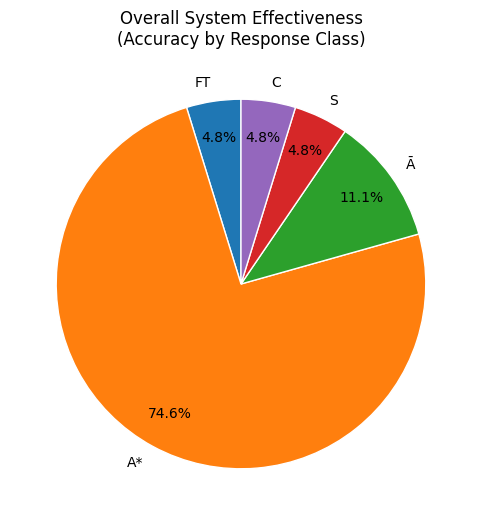

Counts: Counter({'A*': 47, 'Ā': 7, 'FT': 3, 'S': 3, 'C': 3})
Rates (%): {'FT': '4.8', 'A*': '74.6', 'Ā': '11.1', 'S': '4.8', 'C': '4.8'}


In [3]:
from collections import Counter
import matplotlib.pyplot as plt

labels = [r["label"] for r in rows]
total = len(labels)
counts = Counter(labels)
rates  = {k: (v/total)*100 for k,v in counts.items()}

plt.figure(figsize=(6,6))
vals = list(counts.values())
labs = list(counts.keys())
plt.pie(
    vals, labels=labs, autopct="%1.1f%%", startangle=90,
    pctdistance=0.8, wedgeprops=dict(edgecolor="w")  # ✅ correct way
)
plt.title("Overall System Effectiveness\n(Accuracy by Response Class)")
plt.show()

print("Counts:", counts)
print("Rates (%):", {k: f"{v:.1f}" for k,v in rates.items()})



### 2. Task-Specific Performance (Per-Question Accuracy and Weaknesses)

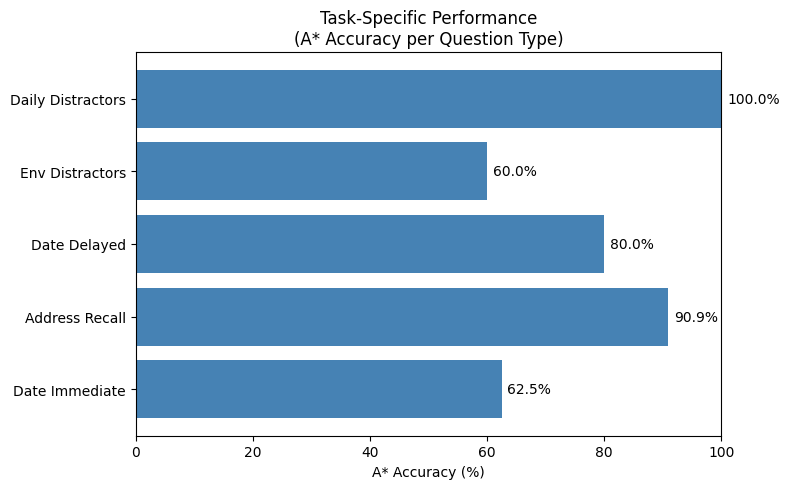

Per-Task A* Accuracy (excluding Functional/Other): {'Date Immediate': 62.5, 'Address Recall': 90.9090909090909, 'Date Delayed': 80.0, 'Env Distractors': 60.0, 'Daily Distractors': 100.0}
Functional/Other (for reporting only): {'Other': 83.33333333333334, 'Functional': 0.0}


In [19]:
ENV_DISTRACTORS = {"Is the light on?", "Can you see a window?", "Is the door open?"}
DAILY_DISTRACTORS = {
    "Have you had any tea or water today?",
    "Have you brushed your teeth today?",
    "Did you drink water this morning?"
}

def task_type(q):
    if q == "What day is today?": return "Date Immediate"
    if q.startswith("Can you tell me again, what day is today?"): return "Date Delayed"
    if q in ENV_DISTRACTORS: return "Env Distractors"
    if q in DAILY_DISTRACTORS: return "Daily Distractors"
    if q == "What was the address?": return "Address Recall"
    if q == "Are you comfortable managing your medicines or finances?": return "Functional"
    return "Other"

for r in rows:
    r["task"] = task_type(r["q"])

# calculate per-task accuracy
bucket_rates = {}
for task in set(r["task"] for r in rows):
    subset = [r for r in rows if r["task"] == task]
    if subset:
        a_star = sum(1 for r in subset if r["label"]=="A*")
        bucket_rates[task] = (a_star/len(subset))*100

# filter out Functional + Other
plot_rates = {k:v for k,v in bucket_rates.items() if k not in ("Functional","Other")}

tasks = list(plot_rates.keys())
vals  = [plot_rates[t] for t in tasks]

plt.figure(figsize=(8,5))
bars = plt.barh(tasks, vals, color="steelblue")
plt.title("Task-Specific Performance\n(A* Accuracy per Question Type)")
plt.xlabel("A* Accuracy (%)")

for bar, val in zip(bars, vals):
    plt.text(val+1, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center")

plt.xlim(0, 100)  # keep percentages on a fixed 0–100 scale
plt.tight_layout()
plt.show()

print("Per-Task A* Accuracy (excluding Functional/Other):", plot_rates)
print("Functional/Other (for reporting only):", {k:v for k,v in bucket_rates.items() if k in ("Functional","Other")})


### 3. Usability Analysis (Response Latency)

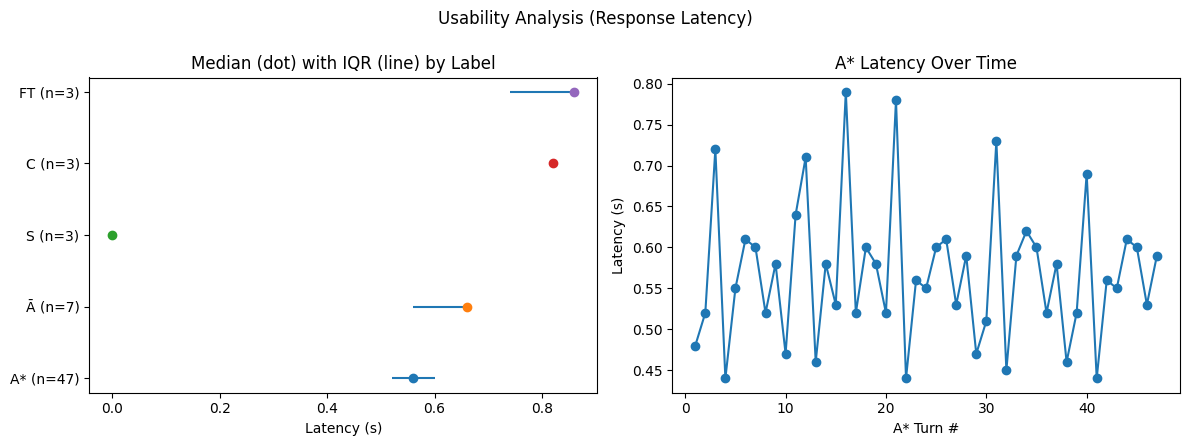


Latency (median & IQR) by label
A*  n=47  median=0.56s  IQR=[0.52, 0.60]
 Ā  n= 7  median=0.66s  IQR=[0.56, 0.67]
 S  n= 3  median=0.00s  IQR=[0.00, 0.00]
 C  n= 3  median=0.82s  IQR=[0.81, 0.82]
FT  n= 3  median=0.86s  IQR=[0.74, 0.86]


In [18]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

# collect
lat_by_label = defaultdict(list)
a_star_series = []  # A* latencies in order
for r in rows:
    lt = r.get("latency_sec")
    if lt is None: 
        continue
    lab = r.get("label")
    if lab:
        lat_by_label[lab].append(float(lt))
    if lab == "A*":
        a_star_series.append(float(lt))

labels_order = ["A*","Ā","S","C","FT"]
stats = []
for lab in labels_order:
    arr = np.array(lat_by_label.get(lab, []), dtype=float)
    if arr.size:
        q1, med, q3 = np.percentile(arr, [25,50,75])
        stats.append((lab, q1, med, q3, len(arr)))
    else:
        stats.append((lab, np.nan, np.nan, np.nan, 0))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4.5))
fig.suptitle("Usability Analysis (Response Latency)")

# 3A: Median + IQR dot-plot
ypos = np.arange(len(stats))
q1s  = [s[1] for s in stats]
meds = [s[2] for s in stats]
q3s  = [s[3] for s in stats]
labs = [f"{s[0]} (n={s[4]})" for s in stats]

# draw only where we have data
for i,(q1,med,q3) in enumerate(zip(q1s,meds,q3s)):
    if np.isfinite(med):
        ax1.hlines(i, q1, q3)       # IQR
        ax1.plot(med, i, "o")       # median

ax1.set_yticks(ypos)
ax1.set_yticklabels(labs)
ax1.set_xlabel("Latency (s)")
ax1.set_title("Median (dot) with IQR (line) by Label")

# 3B: A* latencies over time (simple & intuitive)
if a_star_series:
    ax2.plot(range(1, len(a_star_series)+1), a_star_series, marker="o")
    ax2.set_xlabel("A* Turn #")
    ax2.set_ylabel("Latency (s)")
    ax2.set_title("A* Latency Over Time")
else:
    ax2.text(0.5, 0.5, "No A* latencies available", ha="center", va="center")
    ax2.set_axis_off()

plt.tight_layout()
plt.subplots_adjust(top=0.83)
plt.show()

# quick text table
print("\nLatency (median & IQR) by label")
for lab,q1,med,q3,n in stats:
    if np.isfinite(med):
        print(f"{lab:>2}  n={n:2d}  median={med:.2f}s  IQR=[{q1:.2f}, {q3:.2f}]")
